Run cells one by one, and upload your GPX file in [3]
No data is saved by the owner.

In [ ]:
# Step 1: Install packages
# ======================
!pip install gpxpy matplotlib
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.6 MB/s eta 0:00:00


In [ ]:
# Step 2: Upload GPX file
from google.colab import files
import gpxpy
import matplotlib.pyplot as plt
from math import radians, cos, sin, asin, sqrt
from collections import defaultdict

uploaded = files.upload()
filename = list(uploaded.keys())[0]
print("Uploaded:", filename)

Saving Lunch_Ride.gpx to Lunch_Ride.gpx
Uploaded: Lunch_Ride.gpx


In [ ]:
import gpxpy
from math import radians, sin, cos, sqrt, asin
from collections import defaultdict
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# ==============================================================================
# Constants & Helper Functions
# ==============================================================================
G = 9.80665  # Standard gravity in m/s²

# --- Vehicle and environmental constants for fuel estimation ---
# Tuned for a Honda Civic FD (8th Gen) with A/C on
CAR_MASS = 1350.0  # kg
DRAG_COEFFICIENT = 0.31  # Cd
FRONTAL_AREA = 2.04  # m^2
ROLLING_RESISTANCE = 0.015  # Crr
AC_POWER_DRAW_WATTS = 1500.0  # Watts (Realistic average load)
ENGINE_EFFICIENCY = 0.28  # 28% - Tuned for a known efficient engine

# --- General constants ---
AIR_DENSITY = 1.225  # kg/m^3
FUEL_ENERGY_DENSITY = 34.2 * 1e6  # Joules per Litre for gasoline
IDLE_FUEL_RATE_LPH_AC_ON = 1.4  # Litres per hour when idling with AC

def haversine(lat1, lon1, lat2, lon2):
    """Distance in meters between two lat/lon points."""
    R = 6371000
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return 2 * R * asin(sqrt(a))

def exponential_moving_average(data, alpha=0.5):
    """Calculates the exponential moving average of a list."""
    if not data: return []
    smoothed = [data[0]]
    for i in range(1, len(data)):
        new_val = alpha * data[i] + (1 - alpha) * smoothed[-1]
        smoothed.append(new_val)
    return smoothed

def format_seconds(seconds):
    """Formats seconds into a HH:MM:SS or MM:SS string."""
    h, rem = divmod(int(seconds), 3600)
    m, s = divmod(rem, 60)
    if h > 0:
        return f"{h:02d}:{m:02d}:{s:02d}"
    else:
        return f"{m:02d}:{s:02d}"

# ==============================================================================
# Main Analysis Function
# ==============================================================================
def analyze_gpx(
    filename,
    dist_start=None,
    dist_end=None,
    bin_size=10,
    resolution=2.0,
    alpha=0.7,
    limit=None,
    ignore_below=0,
    show_hist=True,
    show_speed_plot=False,
    detect_braking=True,
    brake_threshold_g=-0.3
):
    """
    Analyzes a GPX file for speed, distance, events, and fuel efficiency.
    All analyses are performed on smoothed data for consistency.

    Args:
        filename (str): Path to the GPX file.
        dist_start (float, optional): The starting distance in km to begin analysis. Defaults to the start of the trip.
        dist_end (float, optional): The ending distance in km to stop analysis. Defaults to the end of the trip.
        bin_size (int, required): Size of range, keep it at 10.
        resoluion (float, required): The least time unit used for calculation, keep it at a value higher than 2 to reduce noise, higher value would lead to oversmoothening.
        alpha (float, required): Denoted the smoothening of the moving average, higher is more noise, lower than 0.5 is less noise.
        limit (float, optional): Will compute stats separately if you drove below this speed at all times.
        ignore_below (float, optional): Will compute stats separately ignoring speeds below this
        show_hist (bool, optional): If True, displays a histogram of speed ranges. Defaults to True.
        detect_braking (bool, optional): If True, detects hard braking events. Defaults to True.
        show_speed_plot (bool, optional): If True, displays an interactive speed vs. distance plot. Defaults to False.
        brake_threshold_g (float, required): Will return braking harsher than this value in gs
    """
    with open(filename, 'r') as f:
        gpx = gpxpy.parse(f)

    # --- Stage 1: Data Extraction & Filtering ---
    # Convert distance range from km to meters for internal calculations
    start_m = dist_start * 1000 if dist_start is not None and dist_start >= 0 else 0
    end_m = dist_end * 1000 if dist_end is not None and dist_end > (dist_start or 0) else float('inf')

    segments_data = []
    absolute_dist = 0.0  # Tracks distance from the very start of the GPX file

    analysis_dist, analysis_time = 0.0, 0.0
    analysis_fuel_L = 0.0
    last_speed_ms = None

    for track in gpx.tracks:
        for segment in track.segments:
            points = segment.points
            i = 0
            while i < len(points) - 1:
                j = i + 1
                while j < len(points):
                    p1, p2 = points[i], points[j]
                    t1, t2 = p1.time, p2.time
                    if not (t1 and t2):
                        j += 1
                        continue

                    dt = (t2 - t1).total_seconds()
                    if dt >= resolution:
                        d = haversine(p1.latitude, p1.longitude, p2.latitude, p2.longitude)
                        dist_before_segment = absolute_dist
                        absolute_dist += d

                        # >>> CORE FILTERING LOGIC <<<
                        # Process this segment only if it falls within the analysis window
                        if absolute_dist > start_m and dist_before_segment < end_m:
                            v = (d / dt) * 3.6 if dt > 0 else 0
                            current_speed_ms = v / 3.6

                            # --- Fuel Calculation ---
                            p1_elev = p1.elevation if p1.elevation is not None else 0
                            p2_elev = p2.elevation if p2.elevation is not None else 0
                            delta_elevation = p2_elev - p1_elev

                            segment_fuel_L = 0.0
                            if current_speed_ms < 1.0: # Idling
                                segment_fuel_L = (IDLE_FUEL_RATE_LPH_AC_ON / 3600) * dt
                            elif last_speed_ms is not None:
                                accel = (current_speed_ms - last_speed_ms) / dt
                                force_drag = 0.5 * AIR_DENSITY * FRONTAL_AREA * DRAG_COEFFICIENT * (current_speed_ms**2)
                                force_rolling = ROLLING_RESISTANCE * CAR_MASS * G
                                force_gravity = CAR_MASS * G * (delta_elevation / d) if d > 0 else 0
                                force_accel = CAR_MASS * accel
                                power_for_motion = (force_drag + force_rolling + force_gravity + force_accel) * current_speed_ms
                                power_for_motion = max(0, power_for_motion)
                                total_power_output = power_for_motion + AC_POWER_DRAW_WATTS
                                energy_from_fuel = (total_power_output * dt) / ENGINE_EFFICIENCY
                                segment_fuel_L = energy_from_fuel / FUEL_ENERGY_DENSITY

                            analysis_fuel_L += segment_fuel_L
                            last_speed_ms = current_speed_ms
                            # --- End Fuel Calculation ---

                            analysis_dist += d
                            analysis_time += dt

                            segments_data.append({
                                'v': v, 'dt': dt, 'd': d,
                                'time': t2,
                                'cumulative_dist': analysis_dist,
                                'cumulative_time': analysis_time
                            })

                        # Stop processing if we've passed the end distance
                        if absolute_dist >= end_m:
                            break # Breaks inner while loop

                        break # Breaks j-loop to find next valid point pair
                    j += 1

                if absolute_dist >= end_m:
                    break # Breaks outer while loop
                i = j
            if absolute_dist >= end_m:
                break # Breaks segment loop
        if absolute_dist >= end_m:
            break # Breaks track loop

    if not segments_data:
        print("No usable speed data found in the specified distance range.")
        return

    raw_speeds = [s['v'] for s in segments_data]
    raw_times = [s['time'] for s in segments_data]

    # --- Stage 2: Data Smoothing ---
    speeds = exponential_moving_average(raw_speeds, alpha=alpha)

    # --- Stage 3: Process Smoothed Data for Analyses ---
    bin_time, bin_dist = defaultdict(float), defaultdict(float)
    limited_time, ignored_dist, ignored_time = 0.0, 0.0, 0.0

    for i in range(len(speeds)):
        s = speeds[i]
        d = segments_data[i]['d']
        dt = segments_data[i]['dt']

        speed_bin = int(s // bin_size) * bin_size
        bin_time[speed_bin] += dt
        bin_dist[speed_bin] += d

        if ignore_below > 0 and s < ignore_below:
            ignored_dist += d
            ignored_time += dt

        if limit and s > limit:
            limited_time += d / (limit / 3.6)
        else:
            limited_time += dt

    # --- Stage 4: Braking Event Analysis ---
    braking_events = []
    if detect_braking:
        brake_threshold_ms2 = brake_threshold_g * G
        for i in range(1, len(speeds)):
            v1_kmh, v2_kmh = speeds[i-1], speeds[i]
            dt = (raw_times[i] - raw_times[i-1]).total_seconds()

            if dt > 0:
                a_ms2 = ((v2_kmh - v1_kmh) / 3.6) / dt
                if a_ms2 < brake_threshold_ms2:
                    event = {
                        'time': raw_times[i], 'decel_ms2': a_ms2, 'decel_g': a_ms2 / G,
                        'v_initial': v1_kmh, 'v_final': v2_kmh,
                        'duration': dt, 'dist_into_trip': segments_data[i]['cumulative_dist']
                    }
                    braking_events.append(event)

    # --- Stage 5: Reporting ---
    print(f"--- Analysis for distance range: {dist_start if dist_start is not None else 0:.1f} km to {f'{dist_end:.1f}' if dist_end is not None and end_m != float('inf') else 'End'} km ---")
    print(f"{'Range (km/h)':<12} {'Time':>8} {'Dist(km)':>10} {'Share':>8}")
    print("-" * 44)
    for b in sorted(bin_time.keys()):
        sec, dist_km = bin_time[b], bin_dist[b] / 1000.0
        if sec == 0: continue
        mm, ss = divmod(int(sec), 60)
        share = (sec / analysis_time) * 100 if analysis_time > 0 else 0
        print(f"{b:02d}-{b+bin_size:<6} {mm:02d}:{ss:02d} {dist_km:10.2f} {share:7.1f}%")

    print("\n--- Summary ---")
    avg_speed_trip = (analysis_dist / analysis_time) * 3.6 if analysis_time > 0 else 0
    top_speed = max(speeds) if speeds else 0
    mm, ss = divmod(int(analysis_time), 60)
    print(f"  Average Speed:  {avg_speed_trip:.1f} km/h")
    print(f"  Top Speed:      {top_speed:.1f} km/h (smoothed)")
    print(f"  Total Distance: {analysis_dist/1000:.2f} km")
    print(f"  Total Time:     {mm:02d}:{ss:02d}")

    if limit:
        extra_time = limited_time - analysis_time
        avg_speed_limited = (analysis_dist / limited_time) * 3.6 if limited_time > 0 else 0
        mm, ss = divmod(int(extra_time), 60)
        pct_change = (extra_time / analysis_time * 100) if analysis_time > 0 else 0
        print(f"\n--- Limiter Analysis (max {limit} km/h) ---")
        print(f"  Avg Speed w/ Limit: {avg_speed_limited:.1f} km/h")
        print(f"  Extra Time:         {mm:02d}:{ss:02d} (+{pct_change:.1f}%)")

    if ignore_below > 0:
        active_dist = analysis_dist - ignored_dist
        active_time = analysis_time - ignored_time
        avg_speed_active = (active_dist / active_time) * 3.6 if active_time > 0 else 0
        mm, ss = divmod(int(active_time), 60)
        print(f"\n--- Active Analysis (<{ignore_below} km/h dropped) ---")
        print(f"  Active Avg Speed: {avg_speed_active:.1f} km/h")
        print(f"  Active Distance:  {active_dist/1000:.2f} km")
        print(f"  Active Time:      {mm:02d}:{ss:02d}")

    if analysis_fuel_L > 0:
        print("\n--- Fuel Efficiency Analysis (Approximation) ---")
        if analysis_dist > 0:
            fuel_efficiency_kml = ((analysis_dist / 1000)/analysis_fuel_L)
            print(f"  Estimated Fuel Used:  {analysis_fuel_L:.2f} L")
            print(f"  Estimated Efficiency: {fuel_efficiency_kml:.2f} km/l")
        else:
            print("  Not enough distance traveled to estimate efficiency.")

    if detect_braking:
        print(f"\n--- Hard Braking Analysis (decel > {abs(brake_threshold_g):.2f} g) ---")
        if braking_events:
            braking_events.sort(key=lambda ev: ev['decel_ms2'])
            worst = braking_events[0]
            print(f"  {len(braking_events)} events found. Worst decel: {worst['decel_ms2']:.2f} m/s² ({worst['decel_g']:.2f} g)")
            for event in braking_events[:5]: # Show top 5 worst events
                dist_km = event['dist_into_trip'] / 1000.0
                print(f"   - At {dist_km:.2f} km: {event['v_initial']:.1f} → {event['v_final']:.1f} km/h in {event['duration']:.2f}s")
                print(f"     └─ Decel: {event['decel_ms2']:.2f} m/s² ({event['decel_g']:.2f} g) at {event['time'].strftime('%H:%M:%S')}")
        else:
            print("  None detected.")

    # --- Stage 6: Plotting ---
    if show_speed_plot:
        print("\n--- Interactive Speed Plot ---")
        if not segments_data:
            print("  No data available to generate speed plot.")
        else:
            print("  Generating and launching interactive plot in browser...")
            plot_distances_km = [(s['cumulative_dist'] / 1000.0) for s in segments_data]
            plot_times_formatted = [format_seconds(s['cumulative_time']) for s in segments_data]

            fig = go.Figure()

            # Add raw speed trace for context
            fig.add_trace(go.Scatter(
                x=plot_distances_km,
                y=raw_speeds,
                mode='lines',
                name='Raw Speed',
                line=dict(color='rgba(173, 216, 230, 0.7)', width=1.5), # Light Blue
                hoverinfo='skip'
            ))

            # Add the main smoothed speed trace
            fig.add_trace(go.Scatter(
                x=plot_distances_km,
                y=speeds,
                mode='lines',
                name='Smoothed Speed',
                line=dict(color='royalblue', width=2.5),
                customdata=plot_times_formatted,
                hovertemplate=(
                    '<b>Dist</b>: %{x:.2f} km<br>'
                    '<b>Speed</b>: %{y:.1f} km/h<br>'
                    '<b>Time</b>: %{customdata}<extra></extra>'
                )
            ))
            fig.update_layout(
                title_text="Interactive Speed vs. Distance",
                xaxis_title="Distance (km)",
                yaxis_title="Speed (km/h)",
                legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
                plot_bgcolor='white',
                xaxis=dict(gridcolor='lightgrey'),
                yaxis=dict(gridcolor='lightgrey'),
                hovermode='x unified'
            )
            fig.show()

    # Block for the Matplotlib Histogram
    if show_hist:
        print("\n--- Histogram ---")
        plot_bin_labels, plot_times, plot_dists = [], [], []
        for b in sorted(bin_time.keys()):
            sec = bin_time[b]
            if sec < 5.0: continue # Ignore insignificant bins
            dist_km = bin_dist[b] / 1000.0
            plot_bin_labels.append(f"{b}-{b+bin_size}")
            plot_times.append(sec / 60)
            plot_dists.append(dist_km)

        if not plot_bin_labels:
            print("  No speed bins with sufficient data to plot.")
            return

        x = range(len(plot_bin_labels))
        width = 0.4
        plt.figure(figsize=(12, 6))
        plt.bar([i - width/2 for i in x], plot_times, width, label="Time (min)", color="skyblue", edgecolor="black")
        plt.bar([i + width/2 for i in x], plot_dists, width, label="Distance (km)", color="lightgreen", edgecolor="black")
        plt.xticks(x, plot_bin_labels, rotation=45)
        plt.xlabel("Speed Range (km/h)")
        plt.ylabel("Value")
        plt.title("Distribution of Time and Distance by Speed Range")
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

--- Analysis for distance range: 0.0 km to End km ---
Range (km/h)     Time   Dist(km)    Share
--------------------------------------------
00-10     14:14       0.26    10.0%
10-20     11:31       2.92     8.1%
20-30     12:36       5.14     8.8%
30-40     12:17       7.21     8.6%
40-50     13:51      10.46     9.7%
50-60     17:04      15.66    12.0%
60-70     18:39      20.18    13.1%
70-80     12:56      16.17     9.1%
80-90     10:00      14.24     7.0%
90-100    09:20      14.88     6.6%
100-110    06:34      11.42     4.6%
110-120    03:22       6.46     2.4%

--- Summary ---
  Average Speed:  52.7 km/h
  Top Speed:      119.5 km/h (smoothed)
  Total Distance: 124.99 km
  Total Time:     142:24

--- Limiter Analysis (max 80 km/h) ---
  Avg Speed w/ Limit: 50.5 km/h
  Extra Time:         05:58 (+4.2%)

--- Active Analysis (<10 km/h dropped) ---
  Active Avg Speed: 58.4 km/h
  Active Distance:  124.74 km
  Active Time:      128:10

--- Fuel Efficiency Analysis (Approximation) --


--- Histogram ---


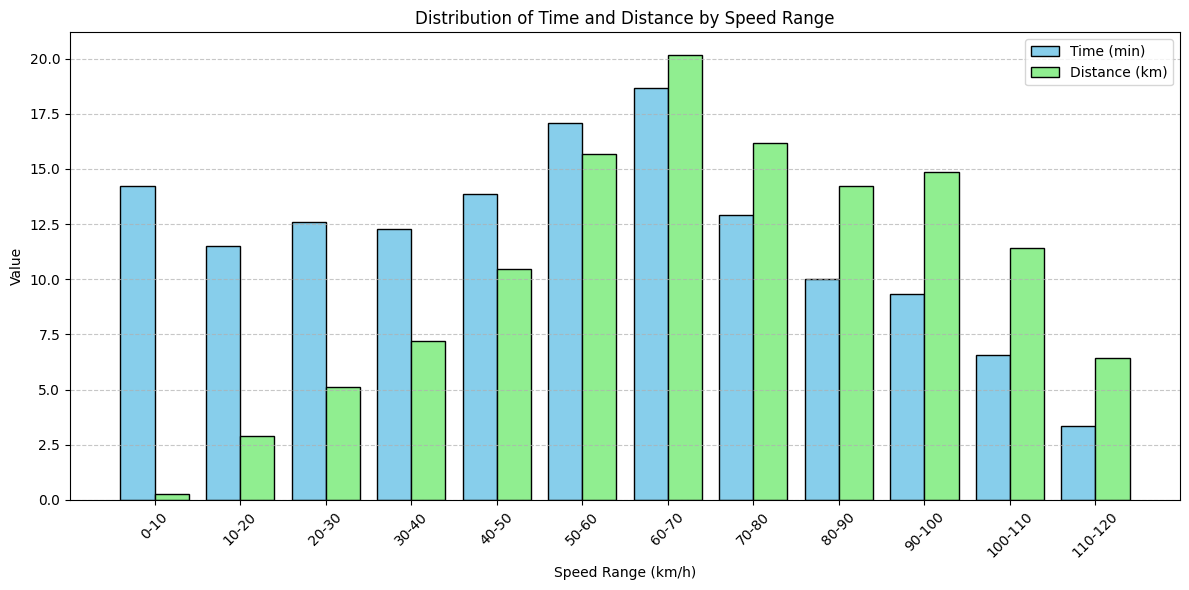

In [ ]:
analyze_gpx(filename, limit=80, ignore_below=10, dist_start=None,dist_end=None, show_speed_plot=True)